<!-- # Biological learning rules are more robust to synaptic pruning -->

In [7]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py
from tqdm.autonotebook import tqdm

import EIANN.utils as ut
import EIANN.plot as pt

from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
figure_name = "Robustness_to_pruning"
model_list = ["vanBP", "bpDale_learned", "bpDale_fixed", "HebbWN_topsup", "bpLike_WT_hebbdend", "BTSP_WT_hebbdend"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

Generating plots for Backprop (ANN)
Generating plots for Backprop (EIANN)
Generating plots for Backprop (EIANN)
Generating plots for Hebb (EIANN)
Generating plots for Dend. Target Prop.
Generating plots for Symmetric B=W (BTSP)


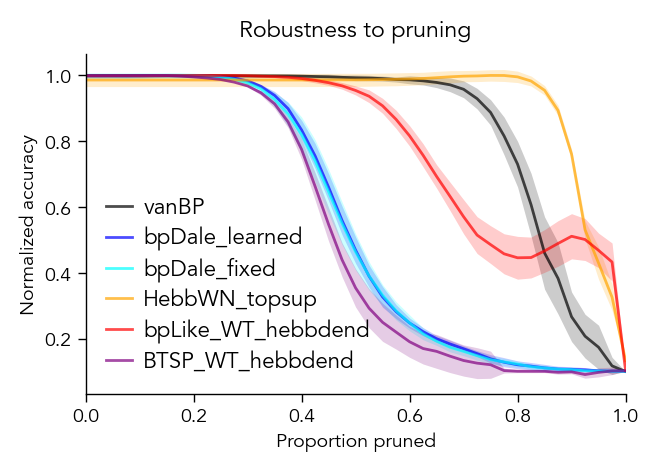

In [21]:
fig = plt.figure(figsize=(3, 2))
axes = gs.GridSpec(nrows=1, ncols=1, figure=fig,                    
                    left=0.05,right=0.95,
                    top=0.95, bottom=0.1)

ax = fig.add_subplot(axes[0, 0])
colors = {"vanBP": 'k',
        "bpDale_learned": 'blue',
        "bpDale_fixed": 'cyan',
        "HebbWN_topsup": 'orange',
        "bpLike_WT_hebbdend": 'red',
        "BTSP_WT_hebbdend": 'purple',
        "bpLike_TCWN_hebbdend": 'magenta'}

for model_key in model_list:
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        print(f"Generating plots for {model_dict['label']}")

        accuracy_list = []
        for seed in model_dict['seeds']:
            if "noise_sensitivity" not in data_dict[seed]:
                print(f"  No noise sensitivity data for seed {seed}, skipping...")
                continue

            fraction_to_prune, accuracy = data_dict[seed]['robustness_to_pruning_E_to_E']
            # fraction_to_prune, accuracy = data_dict[seed]['robustness_to_pruning_all']
            accuracy_list.append(accuracy)

        accuracy_array = np.array(accuracy_list)
        mean_accuracy = np.mean(accuracy_array, axis=0)
        
        mean_accuracy_norm = mean_accuracy / np.max(mean_accuracy)
        std_accuracy_norm = np.std(accuracy_array, axis=0) / np.max(mean_accuracy)
        ax.plot(fraction_to_prune, mean_accuracy_norm, label=model_key, linewidth=1, color=colors[model_key], alpha=0.7)
        ax.fill_between(fraction_to_prune, mean_accuracy_norm - std_accuracy_norm, mean_accuracy_norm + std_accuracy_norm, alpha=0.2, color=colors[model_key], linewidth=0.) 

        # std_accuracy = np.std(accuracy_array, axis=0)
        # ax.plot(fraction_to_prune, mean_accuracy, label=model_dict['label'], linewidth=1, color=colors[model_key], alpha=0.7)
        # ax.fill_between(fraction_to_prune, mean_accuracy - std_accuracy, mean_accuracy + std_accuracy, alpha=0.1, color=colors[model_key])

ax.set_xlabel("Proportion pruned")
ax.set_ylabel("Normalized accuracy")
# ax.set_ylabel("Test accuracy (%)")
ax.set_title("Robustness to pruning")
ax.set_xlim([0, 1])
# ax.set_ylim([0, 100])
ax.legend(frameon=False, fontsize=8, loc='lower left')
plt.show(block=False)

# fig.savefig(f"figures/{figure_name}.svg", dpi=300)
# fig.savefig(f"figures/{figure_name}.png", dpi=300)